
# Computational Statistical Physics — Exercise 07
## Event-driven molecular dynamics in one dimension

This notebook gives a self-contained solution in the style of an exercise hand-in. It follows the provided `edmd_1d_skeleton.py` function structure and solves the mandatory parts of Exercise 07. The optional final sections add compact implementations for a two-dimensional hard-disk extension and a priority-queue version of the one-dimensional algorithm.

We use units in which the particle mass is $m=1$. The coefficient of restitution $e$ is applied both to particle-particle collisions and to collisions with the rigid wall. The main simulations use hard rods with zero radius, $R=0$, as suggested in the exercise sheet for the one-dimensional case.



## Theory used in the implementation

For ordered one-dimensional particles $x_0 < x_1 < \cdots < x_{N-1}$, only neighbouring rods can collide. Therefore the next particle-particle collision time is

$$
 t_{i,i+1} = \frac{x_{i+1}-x_i-2R}{v_i-v_{i+1}},
$$

provided that $v_i>v_{i+1}$; otherwise the two particles are not approaching and the collision time is set to $\infty$. The wall collision times are

$$
 t_i^\mathrm{left} = \frac{R-x_i}{v_i}\quad (v_i<0),
 \qquad
 t_i^\mathrm{right} = \frac{L-R-x_i}{v_i}\quad (v_i>0).
$$

At each event all particles are advanced ballistically, $x_i(t+\Delta t)=x_i(t)+v_i\Delta t$. For equal masses and coefficient of restitution $e$, a particle-particle collision updates the velocities as

$$
\begin{aligned}
 v_i' &= \frac{1-e}{2}v_i + \frac{1+e}{2}v_j,\\
 v_j' &= \frac{1+e}{2}v_i + \frac{1-e}{2}v_j.
\end{aligned}
$$

A wall collision updates $v_i'=-ev_i$. For $e=1$, kinetic energy is conserved by the collision rules; for $e<1$, kinetic energy is dissipated at collisions.


In [1]:

from tqdm.notebook import tqdm
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

FLOAT = np.longdouble
INF = np.longdouble(np.inf)


## Task 1 — One-dimensional event-driven dynamics

In [2]:

def vec_rel(vec, i, j):
    """Calculate the relative scalar/vector between particles i and j."""
    return np.longdouble(vec[i] - vec[j])


def kinetic_energy(v, M=1.0):
    """Total kinetic energy for mass M."""
    v = np.asarray(v, dtype=FLOAT)
    return FLOAT(0.5) * FLOAT(M) * np.sum(v * v)


def initialise_randomly(N, R, L, v_min=-1.0, v_max=1.0, seed=None):
    """
    The positions are returned in sorted order. For R>0 we sample the free coordinates
    and then add the excluded-volume shift 2*R*i, which prevents overlaps.
    """
    rng = np.random.default_rng(seed)
    N = int(N)
    R = FLOAT(R)
    L = FLOAT(L)

    free_length = L - 2 * R * N
    if free_length < 0:
        raise ValueError("The box is too small for this number of rods and radius R.")

    free_positions = np.sort(rng.uniform(0.0, float(free_length), size=N)).astype(FLOAT)
    positions = free_positions + R + 2 * R * np.arange(N, dtype=FLOAT)
    velocities = rng.uniform(v_min, v_max, size=N).astype(FLOAT)
    return positions, velocities


def initialise_cluster(N, R, w, x_left=1.0, velocity=-1.0):
    """
    The particles are evenly spaced and all have the same initial velocity.
    x_left is the position of the leftmost particle centre.
    """
    N = int(N)
    R = FLOAT(R)
    w = FLOAT(w)
    if N > 1 and w < 2 * R * (N - 1):
        raise ValueError("The chosen cluster width is too small for non-overlapping rods.")

    if N == 1:
        positions = np.array([FLOAT(x_left)], dtype=FLOAT)
    else:
        positions = FLOAT(x_left) + np.linspace(0.0, float(w), N, dtype=FLOAT)
    velocities = np.full(N, FLOAT(velocity), dtype=FLOAT)
    return positions, velocities


def collision_finder(x, v, N, L, R=0, threshold=1e-16):
    """
    Returns
    -------
    t_c : np.longdouble
        Time until next event.
    i_c : int
        If wall_collision is True, this is the particle colliding with the wall.
        If wall_collision is False, this is the left particle of the pair (i_c, i_c+1).
    wall_collision : bool
        True for wall collision, False for particle-particle collision.
    """
    x = np.asarray(x, dtype=FLOAT)
    v = np.asarray(v, dtype=FLOAT)
    N = int(N)
    L = FLOAT(L)
    R = FLOAT(R)
    threshold = FLOAT(threshold)

    t_ij = np.full(N, INF, dtype=FLOAT)  # particle collisions; only entries 0,...,N-2 used
    t_w = np.full(N, INF, dtype=FLOAT)   # wall collisions

    if N > 1:
        gaps = x[1:] - x[:-1] - 2 * R
        closing_speeds = v[:-1] - v[1:]
        closing = closing_speeds > threshold
        t_pair = np.full(N - 1, INF, dtype=FLOAT)
        t_pair[closing] = np.maximum(gaps[closing], FLOAT(0.0)) / closing_speeds[closing]
        t_pair[t_pair < 0] = INF
        t_ij[:-1] = t_pair

    moving = np.abs(v) > threshold
    moving_left = moving & (v < 0)
    moving_right = moving & (v > 0)

    t_w[moving_left] = (R - x[moving_left]) / v[moving_left]
    t_w[moving_right] = (L - R - x[moving_right]) / v[moving_right]
    t_w[t_w < 0] = INF

    pair_min = np.min(t_ij)
    wall_min = np.min(t_w)
    t_c = min(pair_min, wall_min)

    if not np.isfinite(float(t_c)):
        return INF, -1, False

    if wall_min <= pair_min:
        return t_c, int(np.argmin(t_w)), True
    else:
        return t_c, int(np.argmin(t_ij)), False


def collision_velocity_update(v, i_c, N, wall_collision, M=1, e_res=1.0):
    """Update velocities after either a wall collision or an equal-mass particle collision."""
    v = np.asarray(v, dtype=FLOAT).copy()
    e = FLOAT(e_res)
    i = int(i_c)

    if wall_collision:
        v[i] = -e * v[i]
    else:
        j = i + 1
        vi, vj = v[i], v[j]
        v[i] = ((1 - e) * vi + (1 + e) * vj) / 2
        v[j] = ((1 + e) * vi + (1 - e) * vj) / 2

    return v


def position_update(x, v, dt, N):
    """Update all positions from t to t+dt using ballistic motion."""
    return np.asarray(x, dtype=FLOAT) + FLOAT(dt) * np.asarray(v, dtype=FLOAT)


def ed_simulation(x, v, n_steps, R, N, L, e_res, t_max=float("inf"), verbose=False,
                  threshold=1e-16, M=1.0):
    """
    The returned time and energy arrays contain the initial state and every resolved event.
    Energy is constant between events, so plotting with drawstyle='steps-post' is natural.
    """
    x = np.asarray(x, dtype=FLOAT).copy()
    v = np.asarray(v, dtype=FLOAT).copy()
    t = FLOAT(0.0)
    t_max = FLOAT(t_max)

    times = [float(t)]
    energies = [float(kinetic_energy(v, M=M))]

    for _ in tqdm(range(int(n_steps)), disable=not verbose):
        t_c, i_c, wall_collision = collision_finder(x, v, N, L, R=R, threshold=threshold)
        if not np.isfinite(float(t_c)):
            break

        if t + t_c > t_max:
            dt = t_max - t
            if dt > 0:
                x = position_update(x, v, dt, N)
                t = t_max
                times.append(float(t))
                energies.append(float(kinetic_energy(v, M=M)))
            break

        x = position_update(x, v, t_c, N)
        t += t_c

        if wall_collision:
            x[i_c] = FLOAT(R) if v[i_c] < 0 else FLOAT(L) - FLOAT(R)
        else:
            x[i_c + 1] = x[i_c] + 2 * FLOAT(R)

        v = collision_velocity_update(v, i_c, N, wall_collision, M=M, e_res=e_res)
        times.append(float(t))
        energies.append(float(kinetic_energy(v, M=M)))

    return x, v, np.asarray(times), np.asarray(energies)


### Short consistency checks

In [3]:

# two equal-mass particles exchange velocities when e=1.
x_test = np.array([1.0, 2.0], dtype=FLOAT)
v_test = np.array([1.0, -0.5], dtype=FLOAT)
t_c, i_c, wall_collision = collision_finder(x_test, v_test, N=2, L=10.0, R=0.0)
v_after = collision_velocity_update(v_test, i_c, N=2, wall_collision=wall_collision, e_res=1.0)

# elastic random-box dynamics conserves kinetic energy to round-off.
x0, v0 = initialise_randomly(N=20, R=0.0, L=10.0, seed=7)
_, _, t_el, E_el = ed_simulation(x0, v0, n_steps=1000, R=0.0, N=20, L=10.0, e_res=1.0)

print("Two-particle e=1 velocity update:", np.asarray(v_after, dtype=float))
print(f"Elastic energy relative drift after {len(t_el)-1} events: {(E_el[-1]-E_el[0])/E_el[0]:.3e}")


Two-particle e=1 velocity update: [-0.5  1. ]
Elastic energy relative drift after 1000 events: 0.000e+00



## Task 2(a) — Random particles in a one-dimensional rigid box

We initialise the positions and velocities uniformly at random and compare an elastic system, \(e=1\), with an inelastic system, here \(e=0.8\). Because the dynamics is event-driven, the energy changes only at collision events.


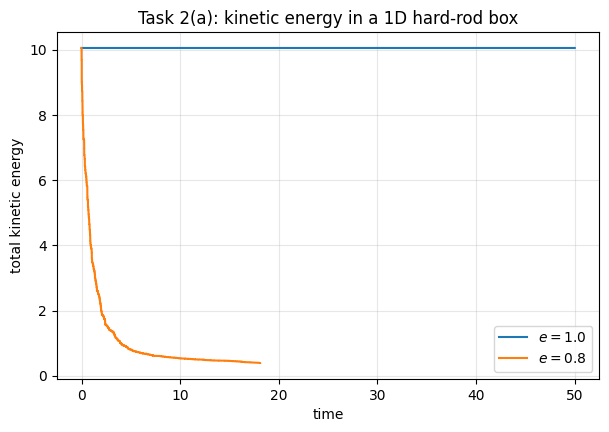

,e,number of recorded events,initial energy,final energy,final / initial
0,1.0,6138,10.056538,10.056538,1.000000
1,0.8,10000,10.056538,0.394597,0.039238


In [4]:

N = 60
L = 10.0
R = 0.0
n_events = 10_000
t_max = 50.0
seed = 12345

x_initial, v_initial = initialise_randomly(N=N, R=R, L=L, v_min=-1.0, v_max=1.0, seed=seed)

box_results = {}
for e in [1.0, 0.8]:
    x_end, v_end, times, energies = ed_simulation(
        x_initial, v_initial, n_steps=n_events, R=R, N=N, L=L,
        e_res=e, t_max=t_max, verbose=False
    )
    box_results[e] = (times, energies, x_end, v_end)

plt.figure(figsize=(7, 4.5))
for e, (times, energies, _, _) in box_results.items():
    plt.plot(times, energies, drawstyle="steps-post", label=fr"$e={e}$")
plt.xlabel("time")
plt.ylabel("total kinetic energy")
plt.title("Task 2(a): kinetic energy in a 1D hard-rod box")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

summary_box = pd.DataFrame([
    {
        "e": e,
        "number of recorded events": len(times) - 1,
        "initial energy": energies[0],
        "final energy": energies[-1],
        "final / initial": energies[-1] / energies[0],
    }
    for e, (times, energies, _, _) in box_results.items()
])
summary_box



### Comment on Task 2(a)

For $e=1$, the particle-particle update conserves total momentum and kinetic energy, and the wall collision only reverses the sign of the velocity. Therefore the total kinetic energy stays constant up to floating-point round-off. For $e<1$, every collision reduces the normal component of the relative velocity, so kinetic energy monotonically decreases. In the inelastic simulation above the particles lose most of their kinetic energy and the event rate decreases once the system becomes slow.



## Task 2(b) — Cluster hitting a wall

The exercise asks for the effective coefficient of restitution

$$
 e_\mathrm{eff}=\sqrt{E_f/E_i},
$$

where $E_i$ is the initial kinetic energy of the incoming cluster and $E_f$ is the kinetic energy after rebound. We use a semi-infinite interpretation of the setup: the physical collision is with the left wall, while the right wall is only an artificial boundary placed very far away. The code below raises an error if this artificial right wall is reached before the rebound criterion is satisfied.

For an outgoing, ordered cluster moving to the right, no further pair collision occurs when $v_i \leq v_{i+1}$ for every neighbouring pair. Together with $v_i\geq 0$ for all particles, this gives the practical stopping criterion used below.


In [5]:

def cluster_has_rebounded(v, threshold=1e-12):
    """True if all particles move away from the left wall and no adjacent pair is closing."""
    v = np.asarray(v, dtype=FLOAT)
    return bool(np.all(v >= -threshold) and np.all(v[:-1] <= v[1:] + threshold))


def simulate_cluster_rebound(N, e_res, R=0.0, spacing=1.0, distance_to_wall=1.0,
                             v0=1.0, max_events=200_000, threshold=1e-16,
                             right_margin=None, return_history=False):
    """
    The right wall is an artificial far-away boundary. It is not part of the
    rebound measurement; if it is reached, the chosen margin was insufficient.
    """
    N = int(N)
    width = spacing * max(N - 1, 0)
    x, v = initialise_cluster(N=N, R=R, w=width, x_left=distance_to_wall + R,
                              velocity=-abs(v0))

    # right wall: only a numerical boundary, not part of the physical setup.
    if right_margin is None:
        right_margin = 1000.0 * max(1, N) + 10.0
    L = distance_to_wall + width + 2 * R + right_margin

    t = FLOAT(0.0)
    Ei = kinetic_energy(v)
    times = [float(t)]
    energies = [float(Ei)]
    events_done = 0

    for _ in range(int(max_events)):
        if cluster_has_rebounded(v):
            break

        t_c, i_c, wall_collision = collision_finder(x, v, N, L, R=R, threshold=threshold)
        if not np.isfinite(float(t_c)):
            break

        x = position_update(x, v, t_c, N)
        t += t_c

        if wall_collision:
            # v[i_c] > 0 means that the artificial right wall would be hit.
            if v[i_c] > 0:
                raise RuntimeError(
                    "Artificial right wall reached before rebound detection; "
                    "increase right_margin or max_events."
                )
            x[i_c] = FLOAT(R)
        else:
            x[i_c + 1] = x[i_c] + 2 * FLOAT(R)

        v = collision_velocity_update(v, i_c, N, wall_collision, e_res=e_res)
        # remove velocities far below the physical scale of the run.
        v[np.abs(v) < FLOAT(1e-30)] = FLOAT(0.0)
        events_done += 1

        if return_history:
            times.append(float(t))
            energies.append(float(kinetic_energy(v)))
    else:
        print(f"Warning: maximum number of events reached for N={N}, e={e_res}.")

    Ef = kinetic_energy(v)
    e_eff = np.sqrt(Ef / Ei)
    if return_history:
        return float(e_eff), events_done, float(t), x, v, np.asarray(times), np.asarray(energies)
    return float(e_eff), events_done, float(t), x, v


def scan_critical_cluster_size(e_values, threshold_eff=1e-4, max_N=60):
    """Scan N until e_eff < threshold_eff for each restitution coefficient."""
    all_curves = {}
    summary = []
    for e in e_values:
        Ns = []
        eeffs = []
        event_counts = []
        Nc = None
        for N in range(1, max_N + 1):
            e_eff, events, t_final, _, _ = simulate_cluster_rebound(N, e)
            Ns.append(N)
            eeffs.append(e_eff)
            event_counts.append(events)
            if e_eff < threshold_eff:
                Nc = N
                break
        all_curves[e] = {"N": np.asarray(Ns), "e_eff": np.asarray(eeffs), "events": np.asarray(event_counts)}
        summary.append({
            "e": e,
            "N_c for e_eff < 1e-4": Nc,
            "last N simulated": Ns[-1],
            "last e_eff": eeffs[-1],
            "events in last run": event_counts[-1],
        })
    return all_curves, pd.DataFrame(summary)


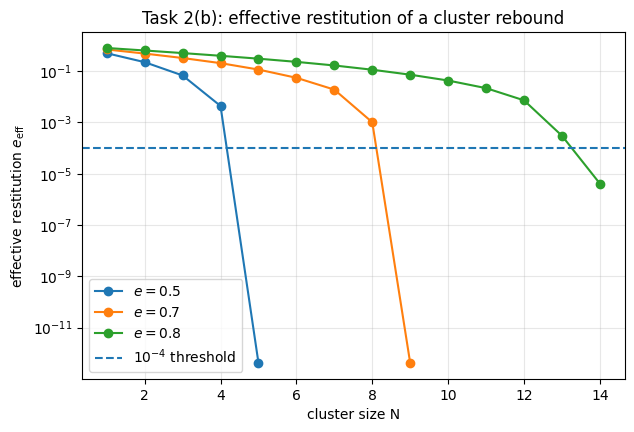

,e,N_c for e_eff < 1e-4,last N simulated,last e_eff,events in last run
0,0.5,5,5,4.226482e-13,446
1,0.7,9,9,4.143960e-13,1742
2,0.8,14,14,4.113242e-06,2601


In [6]:

e_values = [0.5, 0.7, 0.8]
curves, summary_cluster = scan_critical_cluster_size(e_values, threshold_eff=1e-4, max_N=40)

plt.figure(figsize=(7, 4.5))
for e, data in curves.items():
    plt.semilogy(data["N"], data["e_eff"], marker="o", label=fr"$e={e}$")
plt.axhline(1e-4, linestyle="--", label=r"$10^{-4}$ threshold")
plt.xlabel("cluster size N")
plt.ylabel(r"effective restitution $e_{\mathrm{eff}}$")
plt.title("Task 2(b): effective restitution of a cluster rebound")
plt.legend()
plt.grid(alpha=0.3, which="both")
plt.show()

summary_cluster



### Comment on Task 2(b)

The effective restitution decreases rapidly with the number of particles. This happens because the incoming energy is not lost in a single collision only; it is redistributed through many particle-particle collisions while each normal relative collision dissipates a factor controlled by $e$. The more inelastic the microscopic collisions are, the smaller the cluster size needed to make the macroscopic rebound practically vanish. The table above gives one numerical estimate of $N_c$ for three different values of $e<1$ using the stopping criterion $e_\mathrm{eff}<10^{-4}$.

A few implementation conventions are worth stating explicitly. In `collision_finder`, pair collisions return `wall_collision=False`; exact ties between wall and pair candidates are resolved by the deterministic convention that wall events come first. In the cluster experiment the right wall is only an artificial far-away boundary, and the code checks that it is not reached before the rebound state. Finally, velocities below $10^{-30}$ are rounded to zero only to suppress floating-point ghosts after strong dissipation.



# Task 3 — Two-dimensional hard disks

The following compact implementation uses the same event-driven idea in two dimensions. The time to a pair collision is obtained by solving

$$
 |\mathbf r_{ij}+\mathbf v_{ij}t|^2=(2R)^2.
$$

For smooth hard disks, only the velocity component along the line of centres is updated; the tangential component is unchanged.


In [7]:

def collision_finder_2d(x, v, L, R, threshold=1e-14):
    """Naive O(N^2) next-event search for hard disks in a square box."""
    x = np.asarray(x, dtype=FLOAT)
    v = np.asarray(v, dtype=FLOAT)
    N = x.shape[0]
    L = FLOAT(L)
    R = FLOAT(R)
    threshold = FLOAT(threshold)

    best_t = INF
    best_event = ("none", -1, -1)  # (kind, i, j_or_axis)

    # pair events.
    for i in range(N):
        for j in range(i + 1, N):
            dr = x[i] - x[j]
            dv = v[i] - v[j]
            a = np.dot(dv, dv)
            b = 2 * np.dot(dr, dv)
            c = np.dot(dr, dr) - (2 * R) ** 2
            D = b * b - 4 * a * c
            if a > threshold and b < 0 and D >= 0:
                t = (-b - np.sqrt(D)) / (2 * a)
                if threshold < t < best_t:
                    best_t = FLOAT(t)
                    best_event = ("pair", i, j)

    # wall events. j_or_axis is 0 for x-wall and 1 for y-wall.
    for i in range(N):
        for axis in range(2):
            if abs(v[i, axis]) <= threshold:
                continue
            if v[i, axis] < 0:
                t = (R - x[i, axis]) / v[i, axis]
            else:
                t = (L - R - x[i, axis]) / v[i, axis]
            if threshold < t < best_t:
                best_t = FLOAT(t)
                best_event = ("wall", i, axis)

    return best_t, best_event


def collision_velocity_update_2d(x, v, event, R, e_res=1.0):
    """Velocity update for a 2D hard-disk pair or wall collision."""
    v = np.asarray(v, dtype=FLOAT).copy()
    kind, i, j_or_axis = event
    e = FLOAT(e_res)

    if kind == "wall":
        axis = j_or_axis
        v[i, axis] = -e * v[i, axis]
    elif kind == "pair":
        j = j_or_axis
        n = x[i] - x[j]
        n = n / np.sqrt(np.dot(n, n))
        g_n = np.dot(v[i] - v[j], n)
        impulse = FLOAT(0.5) * (1 + e) * g_n * n
        v[i] -= impulse
        v[j] += impulse
    return v


def ed_simulation_2d(x, v, n_events, L, R, e_res=1.0, threshold=1e-14):
    """Naive O(N^2) 2D hard-disk event-driven dynamics in a square box."""
    x = np.asarray(x, dtype=FLOAT).copy()
    v = np.asarray(v, dtype=FLOAT).copy()
    t = FLOAT(0.0)
    times = [float(t)]
    energies = [float(kinetic_energy(v.reshape(-1)))]

    for _ in range(int(n_events)):
        dt, event = collision_finder_2d(x, v, L, R, threshold=threshold)
        if not np.isfinite(float(dt)):
            break
        x += dt * v
        t += dt

        # correct wall contacts.
        if event[0] == "wall":
            i, axis = event[1], event[2]
            x[i, axis] = FLOAT(R) if v[i, axis] < 0 else FLOAT(L) - FLOAT(R)

        v = collision_velocity_update_2d(x, v, event, R, e_res=e_res)
        times.append(float(t))
        energies.append(float(kinetic_energy(v.reshape(-1))))

    return x, v, np.asarray(times), np.asarray(energies)


In [8]:

# elastic 2D collisions conserve kinetic energy.
x2 = np.array([[1.0, 1.0], [3.0, 1.0], [2.0, 3.0]], dtype=FLOAT)
v2 = np.array([[1.0, 0.2], [-0.2, 0.0], [0.1, -0.3]], dtype=FLOAT)
_, _, t2, E2 = ed_simulation_2d(x2, v2, n_events=20, L=5.0, R=0.2, e_res=1.0)
print(f"2D optional check: relative energy drift after {len(t2)-1} events = {(E2[-1]-E2[0])/E2[0]:.3e}")


2D optional check: relative energy drift after 20 events = 0.000e+00



# Task 4 — Priority queue version in 1D

The basic implementation above recomputes all candidate events after each collision. The priority-queue version below stores candidate events in a heap and uses collision counters to discard invalid events lazily. This follows the hint in the sheet: an event is valid only if the collision counters of its particles still match the counters stored when the event was inserted.


In [9]:

import heapq


class EDMD1DPriorityQueue:
    """One-dimensional hard-rod EDMD with lazy invalidation of heap events."""

    def __init__(self, x, v, L, R=0.0, e_res=1.0, M=1.0, threshold=1e-16):
        order = np.argsort(x)
        self.x = np.asarray(x, dtype=FLOAT)[order].copy()
        self.v = np.asarray(v, dtype=FLOAT)[order].copy()
        self.N = len(self.x)
        self.L = FLOAT(L)
        self.R = FLOAT(R)
        self.e = FLOAT(e_res)
        self.M = FLOAT(M)
        self.threshold = FLOAT(threshold)
        self.t = FLOAT(0.0)
        self.t_last = np.zeros(self.N, dtype=FLOAT)
        self.count = np.zeros(self.N, dtype=np.int64)
        self.heap = []

        for i in range(self.N):
            self._schedule_wall(i)
        for i in range(self.N - 1):
            self._schedule_pair(i)

    def _position_at(self, i, t=None):
        if t is None:
            t = self.t
        return self.x[i] + self.v[i] * (FLOAT(t) - self.t_last[i])

    def _advance(self, i, t=None):
        if t is None:
            t = self.t
        self.x[i] = self._position_at(i, t)
        self.t_last[i] = FLOAT(t)

    def _push(self, event_time, kind, i, j=-1):
        if np.isfinite(float(event_time)):
            ci = int(self.count[i])
            cj = int(self.count[j]) if j >= 0 else -1
            heapq.heappush(self.heap, (float(event_time), kind, int(i), int(j), ci, cj))

    def _schedule_wall(self, i):
        x_i = self._position_at(i, self.t)
        v_i = self.v[i]
        if abs(v_i) <= self.threshold:
            return
        if v_i < 0:
            dt = (self.R - x_i) / v_i
        else:
            dt = (self.L - self.R - x_i) / v_i
        if dt > self.threshold:
            self._push(self.t + dt, "wall", i)

    def _schedule_pair(self, i):
        if i < 0 or i >= self.N - 1:
            return
        xi = self._position_at(i, self.t)
        xj = self._position_at(i + 1, self.t)
        closing = self.v[i] - self.v[i + 1]
        gap = xj - xi - 2 * self.R
        if closing > self.threshold:
            dt = gap / closing
            if dt > self.threshold:
                self._push(self.t + dt, "pair", i, i + 1)

    def _valid(self, event):
        event_time, kind, i, j, ci, cj = event
        if ci != self.count[i]:
            return False
        if j >= 0 and cj != self.count[j]:
            return False
        return event_time >= float(self.t) - 1e-14

    def step(self):
        """Resolve one valid event from the heap."""
        while self.heap:
            event = heapq.heappop(self.heap)
            if self._valid(event):
                break
        else:
            return False

        event_time, kind, i, j, _, _ = event
        self.t = FLOAT(event_time)
        self._advance(i, self.t)

        if kind == "wall":
            self.x[i] = self.R if self.v[i] < 0 else self.L - self.R
            self.v[i] = -self.e * self.v[i]
            self.count[i] += 1
            self._schedule_wall(i)
            self._schedule_pair(i - 1)
            self._schedule_pair(i)

        elif kind == "pair":
            self._advance(j, self.t)
            self.x[j] = self.x[i] + 2 * self.R
            vi, vj = self.v[i], self.v[j]
            self.v[i] = ((1 - self.e) * vi + (1 + self.e) * vj) / 2
            self.v[j] = ((1 + self.e) * vi + (1 - self.e) * vj) / 2
            self.count[i] += 1
            self.count[j] += 1
            self._schedule_wall(i)
            self._schedule_wall(j)
            self._schedule_pair(i - 1)
            self._schedule_pair(i)
            self._schedule_pair(j)

        return True

    def current_positions(self):
        for i in range(self.N):
            self._advance(i, self.t)
        return self.x.copy()

    def simulate(self, n_events):
        times = [float(self.t)]
        energies = [float(kinetic_energy(self.v, M=self.M))]
        for _ in range(int(n_events)):
            if not self.step():
                break
            times.append(float(self.t))
            energies.append(float(kinetic_energy(self.v, M=self.M)))
        self.current_positions()
        return self.x.copy(), self.v.copy(), np.asarray(times), np.asarray(energies)


In [10]:

# compare the heap-based code with the simple code for an elastic test.
x_pq, v_pq = initialise_randomly(N=12, R=0.0, L=10.0, seed=11)
_, _, t_simple, E_simple = ed_simulation(x_pq, v_pq, n_steps=200, R=0.0, N=12, L=10.0, e_res=1.0)
solver_pq = EDMD1DPriorityQueue(x_pq, v_pq, L=10.0, R=0.0, e_res=1.0)
_, _, t_heap, E_heap = solver_pq.simulate(200)
print(f"Priority-queue check: max |t_simple - t_heap| = {np.max(np.abs(t_simple - t_heap)):.3e}")
print(f"Priority-queue check: max |E_simple - E_heap| = {np.max(np.abs(E_simple - E_heap)):.3e}")


Priority-queue check: max |t_simple - t_heap| = 2.842e-14
Priority-queue check: max |E_simple - E_heap| = 0.000e+00



## Remarks

The required one-dimensional event-driven algorithm is exact between events because all particles move ballistically. For elastic collisions, the simulation reproduces kinetic-energy conservation. For inelastic collisions, the kinetic energy decreases at events and a many-particle cluster can have an effective restitution that is much smaller than the microscopic restitution coefficient.
